#  Salary Prediction Model
This notebook builds a salary prediction model using a sample salary dataset. It is organized into clear sections with beginner-friendly explanations and uses Python, Pandas, Matplotlib, Seaborn, and Scikit-learn.

## 1. Import Libraries

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

sns.set(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (8, 5)

## 2. Load Dataset

In [63]:
data_path = 'salary_data.csv'
salary_df = pd.read_csv(data_path)
salary_df.head()

,Experience,EducationLevel,Age,JobRole,Salary
0,1,Bachelors,23,Software Engineer,45000
1,3,Masters,27,Data Scientist,65000
2,5,PhD,34,Data Scientist,90000
3,2,Bachelors,25,Business Analyst,52000
4,4,Masters,29,Software Engineer,72000


## 3. Dataset Overview

In [64]:
print('Dataset shape:', salary_df.shape)
print('Columns:')
print(salary_df.columns.tolist())
print('Data types:')
print(salary_df.dtypes)
print('Summary statistics:')
print(salary_df.describe(include='all'))

Dataset shape: (52, 5)
Columns:
['Experience', 'EducationLevel', 'Age', 'JobRole', 'Salary']
Data types:
Experience         int64
EducationLevel    object
Age                int64
JobRole           object
Salary             int64
dtype: object
Summary statistics:
        Experience EducationLevel        Age            JobRole         Salary
count    52.000000             52  52.000000                 52      52.000000
unique         NaN              4        NaN                  6            NaN
top            NaN        Masters        NaN  Software Engineer            NaN
freq           NaN             20        NaN                 11            NaN
mean      4.403846            NaN  32.192308                NaN   80980.769231
std       2.198570            NaN   6.352515                NaN   26032.777518
min       1.000000            NaN  22.000000                NaN   40000.000000
25%       3.000000            NaN  27.750000                NaN   60750.000000
50%       4.000000       

## 4. Data Cleaning

In [65]:
# Copy the original dataset for comparison
salary_clean = salary_df.copy()

# Remove duplicate rows if they exist
duplicates_before = salary_clean.duplicated().sum()
salary_clean = salary_clean.drop_duplicates()
duplicates_after = salary_clean.duplicated().sum()

# Convert data types if needed
salary_clean['Experience'] = pd.to_numeric(salary_clean['Experience'], errors='coerce')
salary_clean['Age'] = pd.to_numeric(salary_clean['Age'], errors='coerce')
salary_clean['Salary'] = pd.to_numeric(salary_clean['Salary'], errors='coerce')

print(f'Duplicates removed: {duplicates_before - duplicates_after}')
print('Data types after conversion:')
print(salary_clean.dtypes)

Duplicates removed: 0
Data types after conversion:
Experience         int64
EducationLevel    object
Age                int64
JobRole           object
Salary             int64
dtype: object


## 5. Missing Value Analysis

Missing values by column:
Experience        0
EducationLevel    0
Age               0
JobRole           0
Salary            0
dtype: int64


C:\Users\megha\AppData\Local\Temp\ipykernel_11168\3607448097.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=missing_values.index, y=missing_values.values, palette='crest')


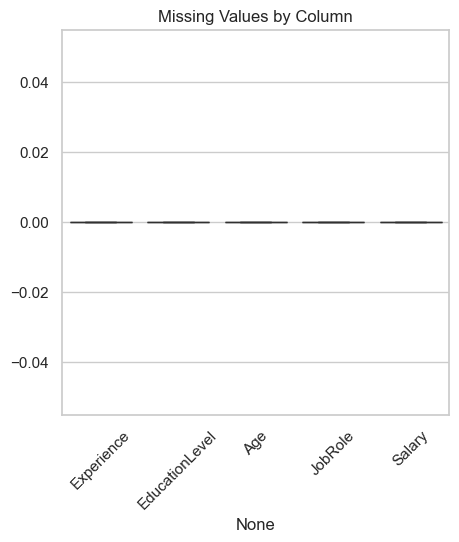

Shape after dropping missing values: (52, 5)


In [78]:
missing_values = salary_clean.isna().sum()
print('Missing values by column:')
print(missing_values)

plt.figure(figsize=(5, 5))
sns.boxplot(x=missing_values.index, y=missing_values.values, palette='crest')
plt.title('Missing Values by Column')
plt.xticks(rotation=45)
plt.show()

salary_clean = salary_clean.dropna()  # Drop rows with missing values for simplicity
print('Shape after dropping missing values:', salary_clean.shape)

## 6. Data Visualization

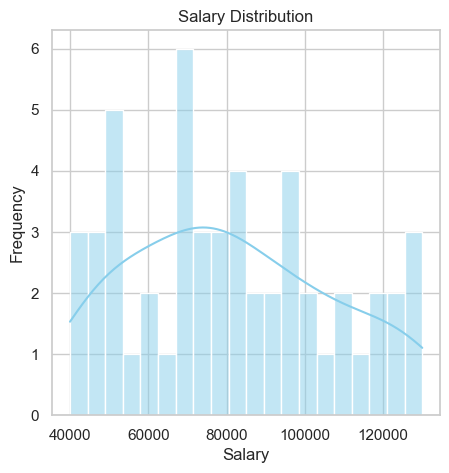

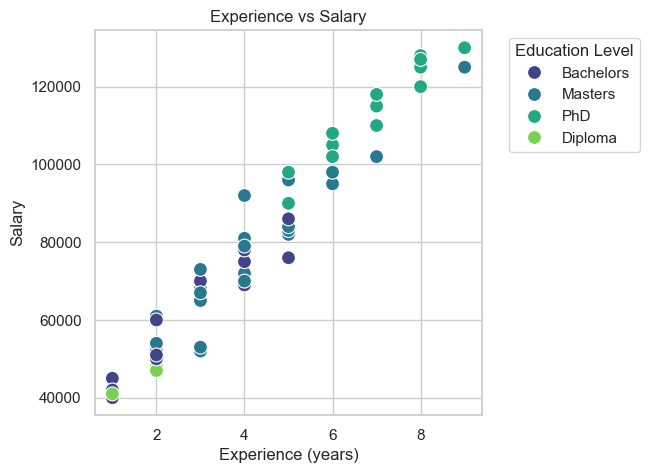

C:\Users\megha\AppData\Local\Temp\ipykernel_11168\4230653021.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=salary_clean, x='EducationLevel', y='Salary', estimator=np.mean, palette='viridis')


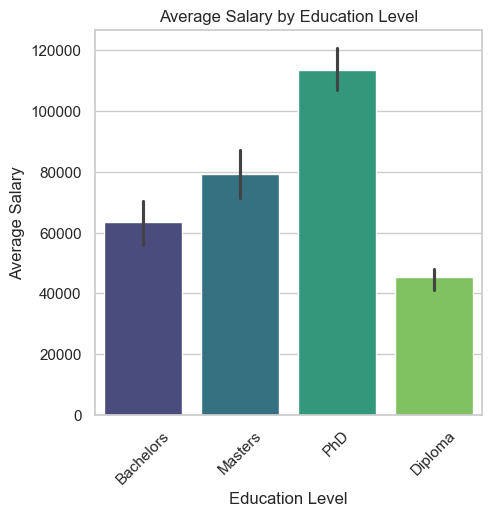

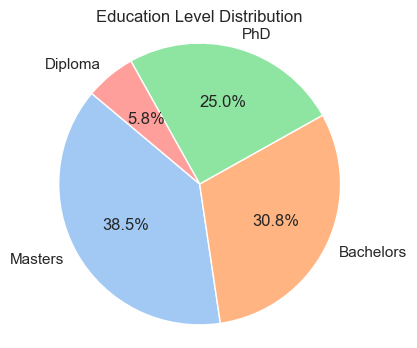

In [77]:
plt.figure(figsize=(5, 5))
sns.histplot(salary_clean['Salary'], kde=True, color='skyblue', bins=20)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(5, 5))
sns.scatterplot(data=salary_clean, x='Experience', y='Salary', hue='EducationLevel', palette='viridis', s=100)
plt.title('Experience vs Salary')
plt.xlabel('Experience (years)')
plt.ylabel('Salary')
plt.legend(title='Education Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

plt.figure(figsize=(5, 5))
sns.barplot(data=salary_clean, x='EducationLevel', y='Salary', estimator=np.mean, palette='viridis')
plt.title('Average Salary by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(4, 4))
education_counts = salary_clean['EducationLevel'].value_counts()
education_counts.plot.pie(autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Education Level Distribution')
plt.ylabel('')
plt.axis('equal')
plt.show()

## 7. Feature Encoding

In [68]:
# Ensure categorical columns are clean before encoding
salary_clean['EducationLevel'] = salary_clean['EducationLevel'].astype(str).str.strip()
salary_clean['JobRole'] = salary_clean['JobRole'].astype(str).str.strip()

salary_encoded = pd.get_dummies(salary_clean, columns=['EducationLevel', 'JobRole'], drop_first=True)
# Convert all columns to numeric values and drop any remaining non-numeric columns
salary_encoded = salary_encoded.apply(pd.to_numeric, errors='coerce')
salary_encoded = salary_encoded.dropna()
non_numeric = salary_encoded.select_dtypes(include=['object', 'string']).columns.tolist()
if non_numeric:
    print('Dropping remaining non-numeric columns:', non_numeric)
    salary_encoded = salary_encoded.drop(columns=non_numeric)

salary_encoded = salary_encoded.apply(pd.to_numeric, errors='coerce')
salary_encoded = salary_encoded.dropna()
print('Data types after encoding:')
print(salary_encoded.dtypes)

print('Encoded columns:')
print(salary_encoded.columns.tolist())

Data types after encoding:
Experience                      int64
Age                             int64
Salary                          int64
EducationLevel_Diploma           bool
EducationLevel_Masters           bool
EducationLevel_PhD               bool
JobRole_Customer Support         bool
JobRole_Data Scientist           bool
JobRole_Marketing Specialist     bool
JobRole_Project Manager          bool
JobRole_Software Engineer        bool
dtype: object
Encoded columns:
['Experience', 'Age', 'Salary', 'EducationLevel_Diploma', 'EducationLevel_Masters', 'EducationLevel_PhD', 'JobRole_Customer Support', 'JobRole_Data Scientist', 'JobRole_Marketing Specialist', 'JobRole_Project Manager', 'JobRole_Software Engineer']


## 8. Feature Selection

In [69]:
features = [col for col in salary_encoded.columns if col != 'Salary']
X = salary_encoded[features]
y = salary_encoded['Salary']

non_numeric_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

if non_numeric_features:
    print('Any non-numeric features left:', non_numeric_features)
    print('Dropping non-numeric feature columns:', non_numeric_features)
    X = X.drop(columns=non_numeric_features)

print('Feature dtypes:')
print(X.dtypes)
print('Features used:')
print(X.columns.tolist())

Feature dtypes:
Experience                      int64
Age                             int64
EducationLevel_Diploma           bool
EducationLevel_Masters           bool
EducationLevel_PhD               bool
JobRole_Customer Support         bool
JobRole_Data Scientist           bool
JobRole_Marketing Specialist     bool
JobRole_Project Manager          bool
JobRole_Software Engineer        bool
dtype: object
Features used:
['Experience', 'Age', 'EducationLevel_Diploma', 'EducationLevel_Masters', 'EducationLevel_PhD', 'JobRole_Customer Support', 'JobRole_Data Scientist', 'JobRole_Marketing Specialist', 'JobRole_Project Manager', 'JobRole_Software Engineer']


## 9. Train-Test Split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set size:', X_train.shape)
print('Test set size:', X_test.shape)

Training set size: (41, 10)
Test set size: (11, 10)


## 10. Linear Regression Model Training

In [71]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Linear Regression model trained successfully.')

Linear Regression model trained successfully.


## 11. Salary Prediction

In [72]:
y_pred = model.predict(X_test)
prediction_df = X_test.copy()
prediction_df['ActualSalary'] = y_test.values
prediction_df['PredictedSalary'] = y_pred
print('Sample salary predictions:')
print(prediction_df[['ActualSalary', 'PredictedSalary']].head())

Sample salary predictions:
    ActualSalary  PredictedSalary
19        125000    116565.255395
41        127000    119597.713264
47         51000     48971.624430
12        130000    129914.253112
43        102000    105626.459838


## 12. Model Evaluation

Mean Squared Error (MSE): 20398476.40
Mean Absolute Error (MAE): 3940.15
R² Score: 0.9789


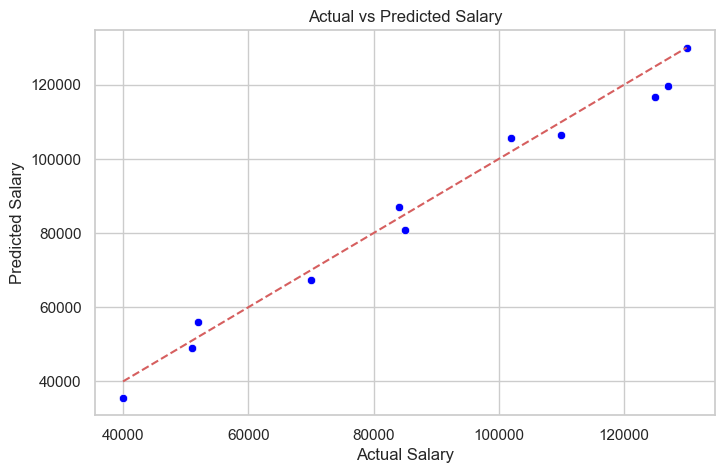

In [73]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'R² Score: {r2:.4f}')

plt.figure()
sns.scatterplot(x=y_test, y=y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Salary')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.show()

## 13. Conclusion

In [74]:
print('Final summary:')
print('Dataset size:', salary_clean.shape)
print('Features used:', features)
print(f'MSE: {mse:.2f}')
print(f'R² Score: {r2:.4f}')
print('Key insights:')
print('- Salary increases with experience and age in this dataset.')
print('- Education level and job role add useful prediction power.')
print('- The model fit can be evaluated using the R² score and the Actual vs Predicted plot.')

Final summary:
Dataset size: (52, 5)
Features used: ['Experience', 'Age', 'EducationLevel_Diploma', 'EducationLevel_Masters', 'EducationLevel_PhD', 'JobRole_Customer Support', 'JobRole_Data Scientist', 'JobRole_Marketing Specialist', 'JobRole_Project Manager', 'JobRole_Software Engineer']
MSE: 20398476.40
R² Score: 0.9789
Key insights:
- Salary increases with experience and age in this dataset.
- Education level and job role add useful prediction power.
- The model fit can be evaluated using the R² score and the Actual vs Predicted plot.
